In [1]:
# Important libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


In [2]:
# load the dataset and target
file_path = r"D:\BPS\dataset\IoT\iot_benign_ddos_reduced.csv"
target = "traffic_class"

In [3]:
df = pd.read_csv(file_path)
print(df.shape)

(3889716, 20)


In [4]:
# spplit features from target
X = df.drop(columns=[target])
y = df[target].astype(str).str.strip().str.lower()

In [5]:
X = X.select_dtypes(include=[np.number]).copy()

In [6]:
# flow byte\s and flow packet\s presented less than 0.05% of inf numbers before. When the reduced 
#dataset was saved, I forgot to exclude them, so instead ill just fix it now 
mask = np.isfinite(X).all(axis=1)
X = X[mask]
y = y[mask]

print( X.shape)

(3887657, 19)


In [7]:
# split into train and test - 80-20
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(3110125, 19)
(777532, 19)


In [10]:
model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("svm", LinearSVC(
        C=1.0,
        loss="squared_hinge",
        dual=False,
        max_iter=3000,
        random_state=42
    ))
])

In [11]:
model.fit(X_train, y_train)
print("\nDone with training")


Done with training


In [12]:
# predict
y_pred = model.predict(X_test)

In [13]:
positive_class = "ddos"

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label=positive_class)
recall = recall_score(y_test, y_pred, pos_label=positive_class)
f1 = f1_score(y_test, y_pred, pos_label=positive_class)

print(f"\nAccuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-score: {f1}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.9016516362027543
Precision: 0.9067303727460156
Recall: 0.9925231984318491
F1-score: 0.9476890746242519

Classification Report:

              precision    recall  f1-score   support

      benign       0.62      0.11      0.18     79640
        ddos       0.91      0.99      0.95    697892

    accuracy                           0.90    777532
   macro avg       0.76      0.55      0.56    777532
weighted avg       0.88      0.90      0.87    777532

Confusion Matrix:

[[  8389  71251]
 [  5218 692674]]


In [14]:
print(y.value_counts(normalize=True) * 100)

traffic_class
ddos      89.757378
benign    10.242622
Name: proportion, dtype: float64


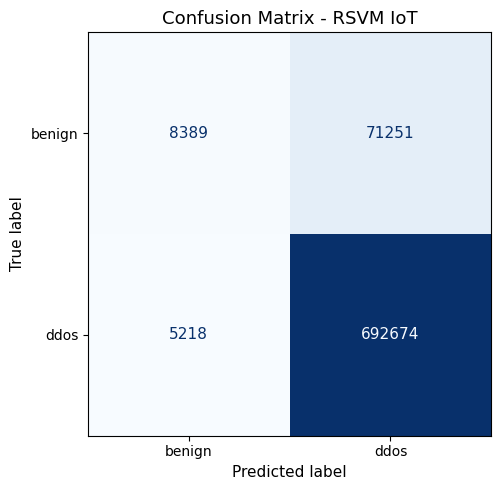

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(6,5))

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["benign", "ddos"],
    cmap="Blues",
    ax=ax,
    colorbar=False  
)

# fix num. size 
for text in disp.text_.ravel():
    text.set_fontsize(11)

ax.set_title("Confusion Matrix - RSVM IoT", fontsize=13)
ax.set_xlabel("Predicted label", fontsize=11)
ax.set_ylabel("True label", fontsize=11)
plt.tight_layout()
plt.savefig("Confusion Matrix - SVM IoT", dpi=300, bbox_inches="tight")
plt.show()